# Feature Usefulness experimentation

In this notebook we will compute the usefulness score for the features of decision trees working on the California Housing Dataset.

In [9]:
import math
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from copy import deepcopy

# Load the California Housing Dataset
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

# We booleanize the prediction by taking the median as a threshold
median_value = np.median(y)
y_binary = (y > median_value).astype(int)

# We make all others categorical features by taking bins
bins_num = 2
X_binned = pd.DataFrame()
for col in X.columns:
    X_binned[col] = pd.qcut(X[col], bins_num, labels=False, duplicates='drop')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_binned, y_binary, test_size=0.2, random_state=42)

# Train a Decision Tree classifier
clf = DecisionTreeClassifier(random_state=42, max_depth = 5)
clf.fit(X_train, y_train)

# Accuracy of the classifier
y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.78      0.77      2077
           1       0.77      0.76      0.77      2051

    accuracy                           0.77      4128
   macro avg       0.77      0.77      0.77      4128
weighted avg       0.77      0.77      0.77      4128

Accuracy: 0.7705910852713178


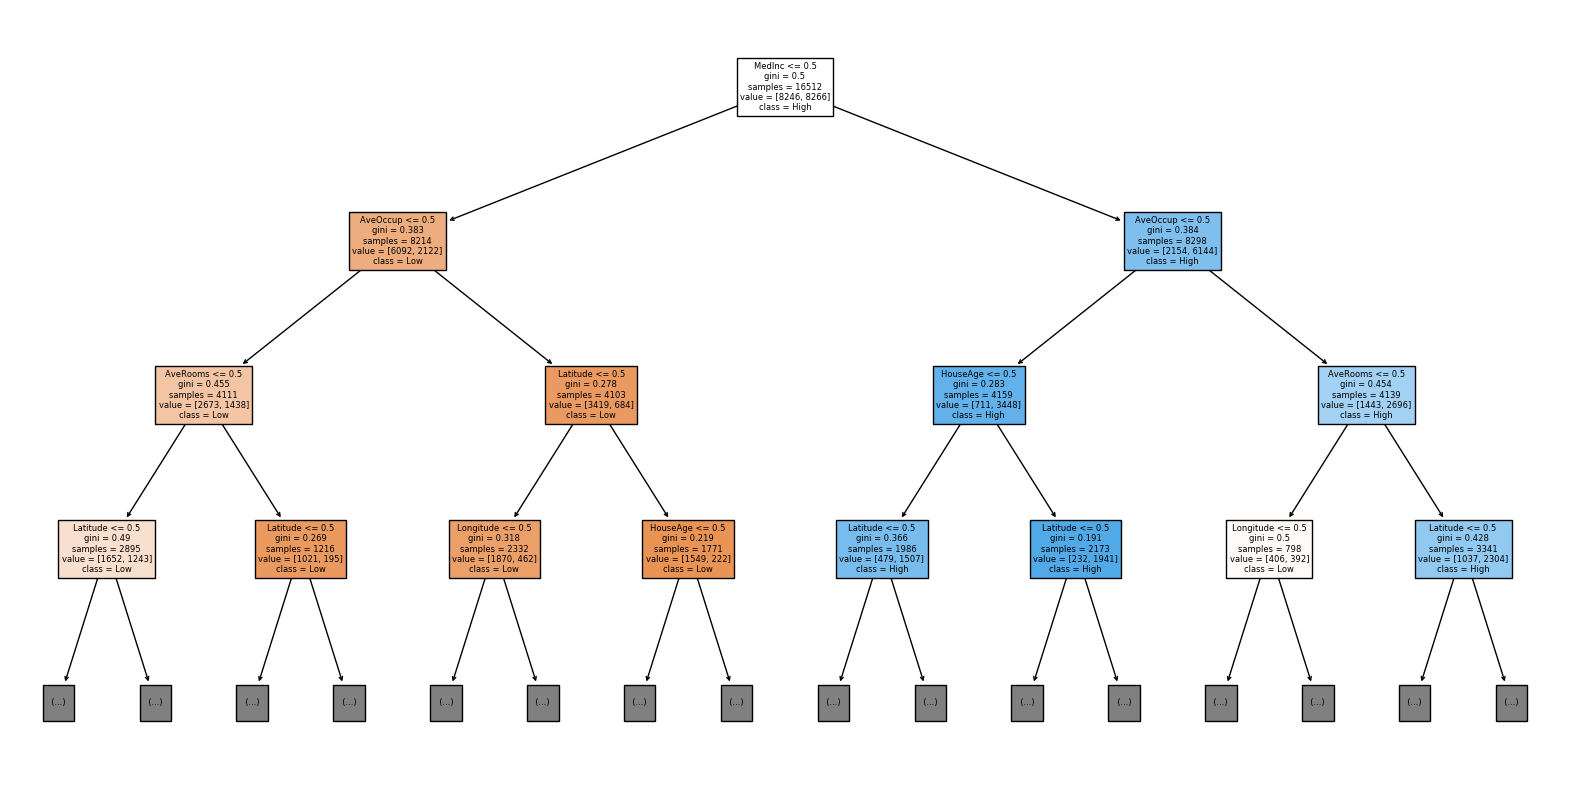

In [3]:
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=["Low", "High"], filled=True, max_depth=3)
plt.show()

In [10]:
class Node:
    feature = None
    threshold = None
    left = None
    right = None

    def __init__(self, feature, threshold, left, right):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right

    def get_feature(self):
        return self.feature

    def set_feature(self, new_feature):
        old_feature = self.feature
        self.feature = new_feature
        return old_feature

    def get_threshold(self):
        return self.threshold

    def set_threshold(self, new_threshold):
        old_threshold = self.threshold
        self.threshold = new_threshold
        return old_threshold

    def get_left(self):
        return self.left

    def set_left(self, node):
        self.left = node

    def get_right(self):
        return self.right

    def set_right(self, node):
        self.right = node

    def is_leaf(self):
        return self.left == None

    def is_true(self):
        return self.feature == "True"

    def is_false(self):
        return not self.is_true()

class Tree:
    root = None
    domains = None

    def __init__(self, root, domains):
        self.root = root
        self.domains = domains

    def get_root(self):
        return self.root

    def _count_recursive(self, node, ranges):
        if node.is_leaf() and node.is_true():
            acum = 1
            for (a, b) in ranges.values():
                acum = acum * (math.floor(b) - math.ceil(a) + 1)
            #print(ranges)
            return max(acum, 0)

        elif not node.is_leaf():
            acum = 0
            
            cur_feature = node.get_feature()
            cur_threshold = node.get_threshold()

            a, b = ranges[cur_feature]

            ranges[cur_feature] = (a, min(cur_threshold, b))
            acum += self._count_recursive(node.get_left(), ranges)

            ranges[cur_feature] = (max(cur_threshold + (math.ceil(cur_threshold) - cur_threshold) / 2, a), b)
            acum += self._count_recursive(node.get_right(), ranges)

            ranges[cur_feature] = (a, b)
            return acum

        else:
            return 0
                
    
    def count(self):
        ranges = {feature: self.domains[feature] for feature in self.domains.keys()}
        
        return self._count_recursive(self.root, ranges)

    def _negate_recursive(self, node):
        if node.is_leaf():
            if node.get_feature() == "True":
                node.set_feature("False")
            else:
                node.set_feature("True")

        else:
            self._negate_recursive(node.get_left())
            self._negate_recursive(node.get_right())
    
    def negate(self):
        return self._negate_recursive(self.root)

    def _conjunction_recursive(self, node, prev_node, other_tree):
        if node.is_leaf():
            if node.is_true():
                if prev_node.get_right() == node:
                    prev_node.set_right(other_tree.get_root())
                else:
                    prev_node.set_left(other_tree.get_root())
        else:
            self._conjunction_recursive(node.get_left(), node, other_tree)
            self._conjunction_recursive(node.get_right(), node, other_tree)

    # Never use more than once in the same tree: we store references instead of copies to avoid using quadratic memory.
    def conjunction(self, other_tree):
        return self._conjunction_recursive(self.root, None, other_tree)

    def _condition_recursive(self, node, feature, value):
        if node.is_leaf():
            return
        else:
            if node.get_feature() == feature:
                if value <= node.get_threshold():
                    node.set_threshold(1e9)
                else:
                    node.set_threshold(-1)

            self._condition_recursive(node.get_left(), feature, value)
            self._condition_recursive(node.get_right(), feature, value)
                
    
    def condition(self, feature, value):
        self._condition_recursive(self.root, feature, value)
    
    def _print_recursive(self, node, tabs):
        if node == None:
            return
        else:
            space = " " * tabs
            print(f'{space}{node.get_feature()} (<= {node.get_threshold()})')
            self._print_recursive(node.get_left(), tabs+3)
            self._print_recursive(node.get_right(), tabs+3)
            
    def print(self):
        self._print_recursive(self.root, 0)

def dec_tree_to_my_tree_rec(node, dec_tree, X):
    if dec_tree.tree_.feature[node] != -2:  # Not a leaf
        feature_name = X.columns[clf.tree_.feature[node]]
        print(feature_name)
        left_node = dec_tree_to_my_tree_rec(dec_tree.tree_.children_left[node], dec_tree, X)
        right_node = dec_tree_to_my_tree_rec(dec_tree.tree_.children_right[node], dec_tree, X)
        threshold = clf.tree_.threshold[node]
        return Node(feature_name, threshold, left_node, right_node)
    else:
        value = clf.tree_.value[node]
        predicted_class = np.argmax(value)
        if predicted_class == 1:
            return Node("True", 1, None, None)
        else:
            return Node("False", 0, None, None)

def dec_tree_to_my_tree(dec_tree, domains, X):
    root = dec_tree_to_my_tree_rec(0, dec_tree, X)
    return Tree(root, domains)

In [4]:


# Mini test of counting
false = Node("False", 0, None, None)
true = Node("True", 1, None, None)
x1 = Node("x", 1.5, deepcopy(true), deepcopy(false))
x2 = Node("x", 0.5, deepcopy(true), x1)
y = Node("y", 0.5, deepcopy(false), deepcopy(true))
z = Node("z", 0.5, x2, y)

domains = {}
domains["x"] = (0, 2)
domains["y"] = (0, 1)
domains["z"] = (0, 1)

tree = Tree(z, domains)
tree.print()

tree.domains
tree.count()

z (<= 0.5)
   x (<= 0.5)
      True (<= 1)
      x (<= 1.5)
         True (<= 1)
         False (<= 0)
   y (<= 0.5)
      False (<= 0)
      True (<= 1)


7

In [21]:
# Minitest of negation
tree_to_negate = deepcopy(tree)
acum = tree_to_negate.count()
tree_to_negate.negate()
tree_to_negate.print()
acum += tree_to_negate.count()
tree_to_negate.negate()
acum

z (<= 0.5)
   x (<= 0.5)
      False (<= 1)
      x (<= 1.5)
         False (<= 1)
         True (<= 0)
   y (<= 0.5)
      True (<= 0)
      False (<= 1)


12

In [22]:
# Minitest of conjunction
same_tree = deepcopy(tree)
same_tree_2 = deepcopy(tree)
same_tree_3 = deepcopy(tree)
opposite_tree = deepcopy(tree)

same_tree_3.conjunction(same_tree)
print(tree.count())

opposite_tree.negate()
same_tree_2.conjunction(opposite_tree)
print(same_tree_2.count())

7
0


In [32]:
# Minitest of conditioning
tree_to_condition = deepcopy(tree)
tree_to_condition.print()
tree_to_condition.count()

tree_to_condition.condition("z", 0)
tree_to_condition.print()
print(tree_to_condition.count())

tree_to_condition = deepcopy(tree)
tree_to_condition.condition("z", 1)
print(tree_to_condition.count())

tree_to_condition = deepcopy(tree)
tree_to_condition.condition("x", 1)
print(tree_to_condition.count())

tree_to_condition = deepcopy(tree)
tree_to_condition.condition("x", 1)
tree_to_condition.condition("y", 1)
print(tree_to_condition.count())

z (<= 0.5)
   x (<= 0.5)
      True (<= 1)
      x (<= 1.5)
         True (<= 1)
         False (<= 0)
   y (<= 0.5)
      False (<= 0)
      True (<= 1)
z (<= 1000000000.0)
   x (<= 0.5)
      True (<= 1)
      x (<= 1.5)
         True (<= 1)
         False (<= 0)
   y (<= 0.5)
      False (<= 0)
      True (<= 1)
8
6
9
12


In [24]:
import math
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Load the California Housing Dataset
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

# We booleanize the prediction by taking the median as a threshold
median_value = np.median(y)
y_binary = (y > median_value).astype(int)

# We make all others categorical features by taking bins
bins_num = 2
X_binned = pd.DataFrame()
for col in X.columns:
    X_binned[col] = pd.qcut(X[col], bins_num, labels=False, duplicates='drop')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_binned, y_binary, test_size=0.2, random_state=42)

# Train a Decision Tree classifier
clf = DecisionTreeClassifier(random_state=42, max_depth=6)
clf.fit(X_train, y_train)

# Accuracy of the classifier
y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.76      0.77      2077
           1       0.76      0.78      0.77      2051

    accuracy                           0.77      4128
   macro avg       0.77      0.77      0.77      4128
weighted avg       0.77      0.77      0.77      4128

Accuracy: 0.7696220930232558


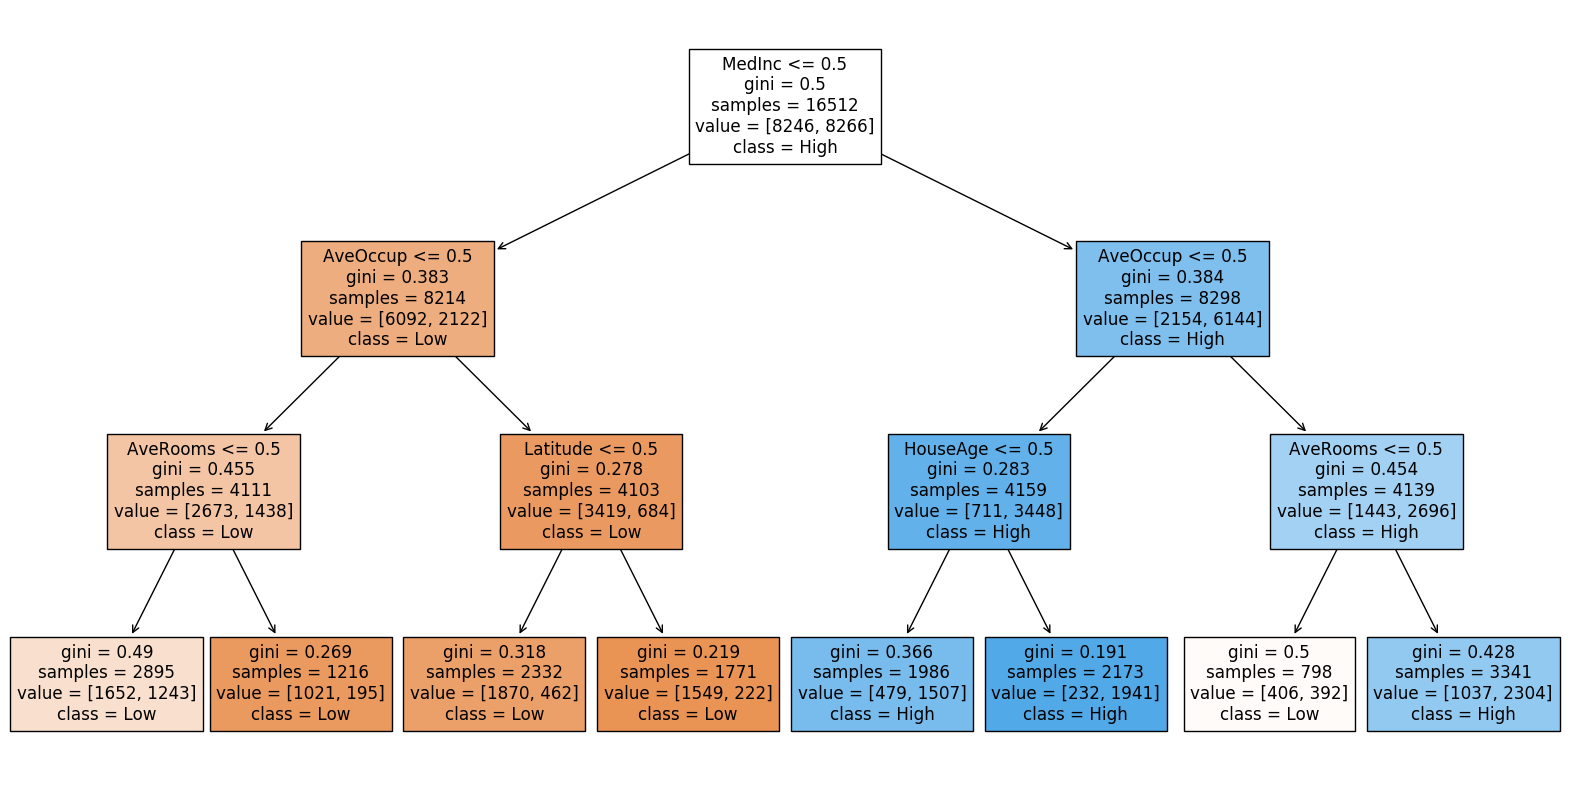

In [6]:
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=["Low", "High"], filled=True, max_depth=3)
plt.show()

In [25]:
domains = {feature: (0, 1) for feature in X_binned.columns.values}
my_tree = dec_tree_to_my_tree(clf, domains)
my_tree.print()
my_tree.count()

MedInc (<= 0.5)
   AveOccup (<= 0.5)
      AveRooms (<= 0.5)
         Latitude (<= 0.5)
            HouseAge (<= 0.5)
               Longitude (<= 0.5)
                  True (<= 1)
                  False (<= 0)
               Longitude (<= 0.5)
                  True (<= 1)
                  True (<= 1)
            HouseAge (<= 0.5)
               Population (<= 0.5)
                  False (<= 0)
                  False (<= 0)
               Population (<= 0.5)
                  False (<= 0)
                  True (<= 1)
         Latitude (<= 0.5)
            HouseAge (<= 0.5)
               AveBedrms (<= 0.5)
                  False (<= 0)
                  False (<= 0)
               Longitude (<= 0.5)
                  True (<= 1)
                  False (<= 0)
            HouseAge (<= 0.5)
               Longitude (<= 0.5)
                  False (<= 0)
                  False (<= 0)
               AveBedrms (<= 0.5)
                  False (<= 0)
                  False (<= 0)


124

In [42]:
def compute_score(tree, feature, num_features):
    tree_0 = deepcopy(tree)
    tree_0.condition(feature, 0)
    tree_1 = deepcopy(tree)
    tree_1.condition(feature, 1)
    tree_0.conjunction(tree_1)
    
    acum = tree_0.count()

    negated_tree_0 = deepcopy(tree)
    negated_tree_0.negate()
    negated_tree_0.condition(feature, 0)
    negated_tree_1 = deepcopy(tree)
    negated_tree_1.negate()
    negated_tree_1.condition(feature, 1)
    negated_tree_0.conjunction(negated_tree_1)

    acum += negated_tree_0.count()

    return 2**num_features - acum

print(compute_score(my_tree, "MedInc", 8))
print(compute_score(my_tree, "HouseAge", 8))
print(compute_score(my_tree, "Population", 8))

112
24
8


Pendientes:
* Pasar de arbol de la libreria al mio (una hora)
* Automatizar generar varios modelos con distintos hiperparametros y distintos sets de entrenamientos (2 horas)
* Agregar otro dataset (2 horas)
* Plottear todo (2 horas)

In [24]:
from sklearn.preprocessing import KBinsDiscretizer

def compute_score(tree, feature, num_features):
    tree_0 = deepcopy(tree)
    tree_0.condition(feature, 0)
    tree_1 = deepcopy(tree)
    tree_1.condition(feature, 1)
    tree_0.conjunction(tree_1)
    
    acum = tree_0.count()

    negated_tree_0 = deepcopy(tree)
    negated_tree_0.negate()
    negated_tree_0.condition(feature, 0)
    negated_tree_1 = deepcopy(tree)
    negated_tree_1.negate()
    negated_tree_1.condition(feature, 1)
    negated_tree_0.conjunction(negated_tree_1)

    acum += negated_tree_0.count()

    return 2**num_features - acum

def train_tree_for_California(max_depth, seed, bins, random_state):
    housing = fetch_california_housing(as_frame=True)
    X = housing.data
    y = housing.target

    # We booleanize the prediction by taking the median as a threshold
    median_value = np.median(y)
    y_binary = (y > median_value).astype(int)

    # We make all others categorical features by taking bins
    X_binned = X

    #for col in X.columns:
     #   threshold = X[col].median()
    #    X_binary[col] = (X[col] > threshold).astype(int)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X_binned, y_binary, test_size=0.2, random_state=seed)

    # Train a Decision Tree classifier
    clf = DecisionTreeClassifier(random_state=random_state, max_depth=max_depth)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(X_binned)
    
    return clf, accuracy

clf_tree, accuracy = train_tree_for_California(3, 30, 2, 30)

features = X_binned.columns.values
domains = {feature: (0, 1) for feature in features}

tree = dec_tree_to_my_tree(clf_tree, domains, X_train)

scores = {}
for feature in features:
    scores[feature] = compute_score(tree, feature, len(features))

scores

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude   
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88  \
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

{'MedInc': -1103999998016,
 'HouseAge': 0,
 'AveRooms': 64,
 'AveBedrms': 0,
 'Population': 0,
 'AveOccup': -47999999872,
 'Latitude': 0,
 'Longitude': 0}

In [13]:
compute_score(tree, "MedInc", 8)
tree.print()

MedInc (<= 0.5)
   AveOccup (<= 0.5)
      AveRooms (<= 0.5)
         False (<= 0)
         True (<= 1)
      Latitude (<= -2.0)
         True (<= 1)
         False (<= 0)
   Latitude (<= -2.0)
      Latitude (<= -2.0)
         False (<= 0)
         False (<= 0)
      Latitude (<= -2.0)
         False (<= 0)
         False (<= 0)


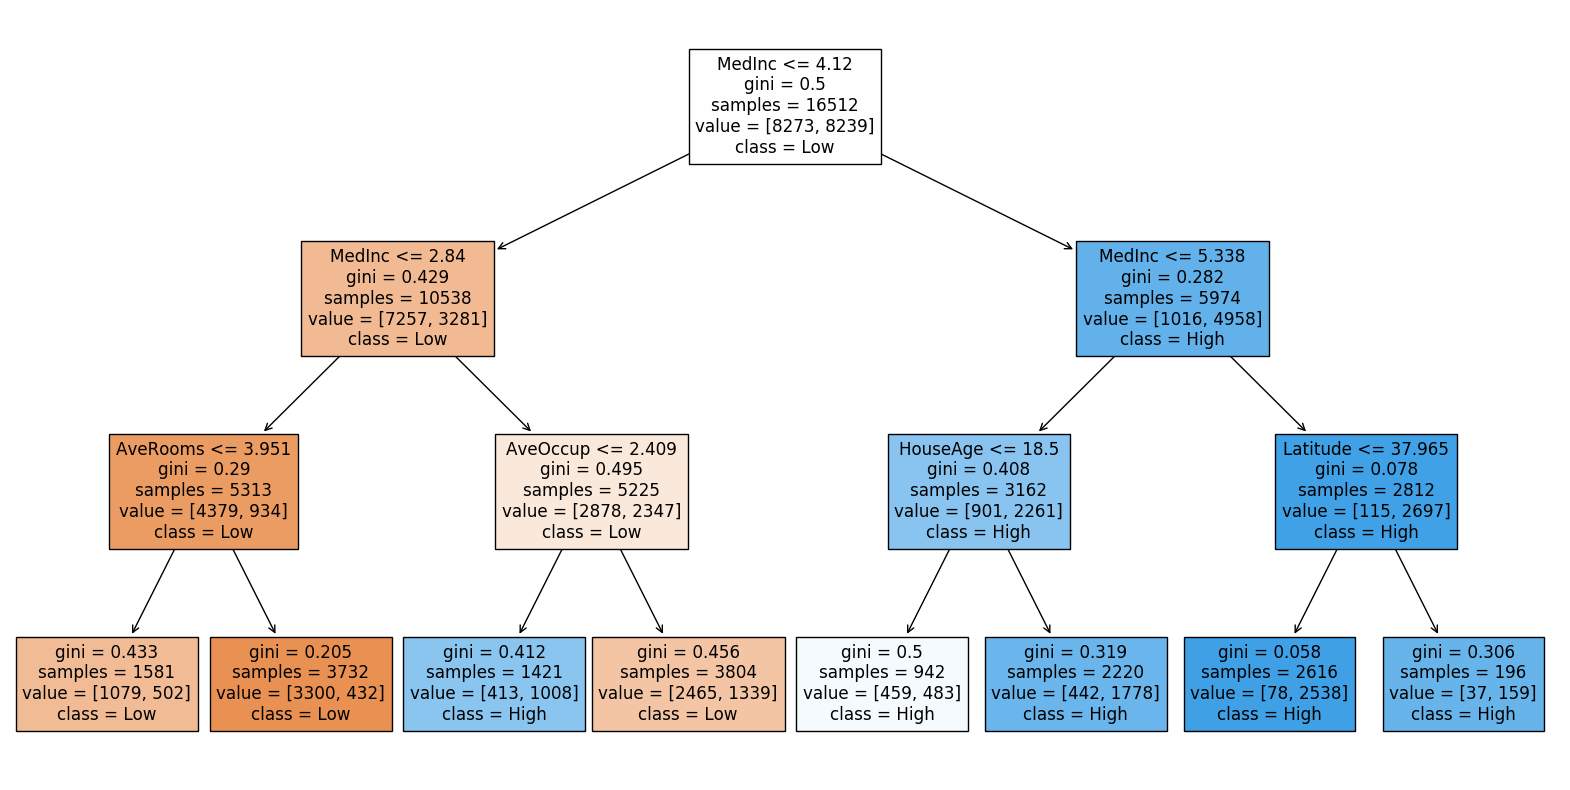

In [25]:
plt.figure(figsize=(20, 10))
plot_tree(clf_tree, feature_names=X.columns, class_names=["Low", "High"], filled=True, max_depth=3)
plt.show()

In [29]:
def dec_tree_to_my_tree_rec(node, dec_tree, X, depth):
    if dec_tree.tree_.feature[node] != -2:  # Not a leaf
        feature_name = X.columns[dec_tree.tree_.feature[node]]
        threshold = dec_tree.tree_.threshold[node]
        print(f'{" " * depth}Node {node}: feature {feature_name}, threshold {threshold}')
        left_node = dec_tree_to_my_tree_rec(dec_tree.tree_.children_left[node], dec_tree, X, depth + 3)
        right_node = dec_tree_to_my_tree_rec(dec_tree.tree_.children_right[node], dec_tree, X, depth+ 3)
        
        return Node(feature_name, threshold, left_node, right_node)
    else:
        value = dec_tree.tree_.value[node]
        predicted_class = np.argmax(value)
        if predicted_class == 1:
            return Node("True", 1, None, None)
        else:
            return Node("False", 0, None, None)

def dec_tree_to_my_tree(dec_tree, domains, X):
    root = dec_tree_to_my_tree_rec(0, dec_tree, X, 0)
    return Tree(root, domains)

tree = dec_tree_to_my_tree(clf_tree, domains, X_train)
#tree.print()

Node 0: feature MedInc, threshold 4.119750022888184
   Node 1: feature MedInc, threshold 2.8402000665664673
      Node 2: feature AveRooms, threshold 3.950626850128174
      Node 5: feature AveOccup, threshold 2.4086925983428955
   Node 8: feature MedInc, threshold 5.337549924850464
      Node 9: feature HouseAge, threshold 18.5
      Node 12: feature Latitude, threshold 37.96500015258789


In [27]:
clf_tree.tree_.children_left
clf_tree.tree_.children_right

array([ 8,  5,  4, -1, -1,  7, -1, -1, 12, 11, -1, -1, 14, -1, -1],
      dtype=int64)